# Berlin Case Study: Crimes in 2012-2019

## The Problem
The city of Berlin hosts a large population (~3.38 million people on average, for the 2012-2019 period) and one of the greatest concentrations of expats in Europe. As more and more people from all over the world move to Berlin — drawn by its economy, vibrant lifestyle, and cultural diversity — the city council needs to take a careful look at crime patterns across the city: understand where and how they are evolving, plan targeted interventions, and advise newcomers on what to be aware of before they arrive.

## Questions Overview
1. Overall, are crime rates across the city constant, or have they been trending in a particular direction?
2. How have individual districts evolved over time, either getting safer, more dangerous, or remaining the same?
3. Is the ratio of violent crime (robbery, assault, injury...) to property crime (theft, burglary, damage...) constant, or does it shift across districts?
4. Is there a single location that leads for violent crimes every year?
5. Which are the bottom 3 locations for amount of drug-related crimes, in the years between 2016 and 2019? And which are the top 3?
6. Are drug crimes a leading indicator for violent crimes across the city?
7. Which locations are generating disproportionate crime relative to their district average?
8. What is the district with the highest number of neighbour disputes, on average, between 2014 and 2018?
9. Which is the top location in each districts that should get targeted enforcement for bike theft?
10. Which district shows the greatest crime volatility year-to-year?


## Imports

In [1]:
import pandas as pd
import seaborn as sns
import sqlalchemy as sa

from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes

## Data Preprocessing

### Data preparation

In [2]:
df: pd.DataFrame = pd.read_csv("data/raw/berlin_crimes_2012_to_2019.csv")

In [3]:
df.head()

,Year,District,Code,Location,Robbery,Street_robbery,Injury,Agg_assault,Threat,Theft,Car,From_car,Bike,Burglary,Fire,Arson,Damage,Graffiti,Drugs,Local
0,2012,Mitte,10111,Tiergarten Süd,70,46,586,194,118,2263,18,328,120,68,16,4,273,26,171,1032
1,2012,Mitte,10112,Regierungsviertel,65,29,474,123,142,3203,10,307,170,37,10,4,380,124,98,870
2,2012,Mitte,10113,Alexanderplatz,242,136,1541,454,304,8988,81,792,822,275,49,27,1538,522,435,3108
3,2012,Mitte,10114,Brunnenstraße Süd,52,25,254,60,66,1916,86,192,396,131,14,5,428,122,213,752
4,2012,Mitte,10221,Moabit West,130,51,629,185,199,2470,94,410,325,161,42,22,516,64,259,1403


In [4]:
df = df.rename(columns={"Local": "Neighbour_disputes"})

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Year                1200 non-null   int64
 1   District            1200 non-null   str  
 2   Code                1200 non-null   int64
 3   Location            1200 non-null   str  
 4   Robbery             1200 non-null   int64
 5   Street_robbery      1200 non-null   int64
 6   Injury              1200 non-null   int64
 7   Agg_assault         1200 non-null   int64
 8   Threat              1200 non-null   int64
 9   Theft               1200 non-null   int64
 10  Car                 1200 non-null   int64
 11  From_car            1200 non-null   int64
 12  Bike                1200 non-null   int64
 13  Burglary            1200 non-null   int64
 14  Fire                1200 non-null   int64
 15  Arson               1200 non-null   int64
 16  Damage              1200 non-null   int64
 17  Graffi

In [6]:
df.describe().round(2)

,Year,Code,Robbery,Street_robbery,Injury,Agg_assault,Threat,Theft,Car,From_car,Bike,Burglary,Fire,Arson,Damage,Graffiti,Drugs,Neighbour_disputes
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2015.50,67022.79,34.23,18.74,276.33,68.75,92.58,1492.31,42.51,215.28,197.71,69.49,15.99,6.28,281.58,62.88,97.86,662.42
std,2.29,34813.75,37.09,22.17,243.70,71.11,68.46,1364.44,28.71,150.03,178.70,57.87,12.68,5.19,203.01,62.29,174.80,534.79
min,2012.00,10111.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00
25%,2013.75,40101.00,10.00,5.00,108.00,22.00,42.00,639.75,22.00,109.00,76.00,28.00,7.00,3.00,133.00,20.00,18.00,269.25
50%,2015.50,70151.50,22.00,11.00,204.50,44.00,75.00,1100.00,37.00,186.00,143.00,59.00,13.00,5.00,244.00,45.00,40.00,553.50
75%,2017.25,90520.00,42.00,23.00,361.00,86.00,124.00,2019.75,57.00,291.00,286.00,96.00,22.00,9.00,382.00,87.00,86.00,870.25
max,2019.00,129900.00,242.00,169.00,1966.00,500.00,420.00,12479.00,197.00,876.00,1288.00,446.00,74.00,31.00,1538.00,530.00,1949.00,3813.00


This dataset contains information about different types of crimes (robbery, assault, arson, drugs...) registered across the various Berlin districts and postal areas. The data available covers the 2012 to 2019 time period. Aside from geographical information (district and location), all remaining data points are numeric.

The data is already well organized and all values are present. We can create our database and upload it as is, with the exceptions of renaming the "Local" columns to "Neighbour_disputes" for clarity (source: [dataset](https://www.kaggle.com/datasets/danilzyryanov/crime-in-berlin-2012-2019/discussion/419136))

**N.B.** For the sake of this exercise, we will not create any aggregate columns at this stage. All aggregations and data manipulation will happen in SQL.

### Database creation

In [7]:
engine: sa.Engine = sa.create_engine("sqlite:///data/db/berlin_crimes.db")

df.to_sql(
    name="berlin_crimes",
    con=engine,
    if_exists="replace",
    index=False,
    dtype={
        "District": sa.VARCHAR,
        "Location": sa.VARCHAR,
        "Year": sa.INTEGER,
        "Robbery": sa.INTEGER,
        "Injury": sa.INTEGER,
        "Agg_assault" : sa.INTEGER,
        "Street_robbery" : sa.INTEGER,
        "Threat" : sa.INTEGER,
        "Theft" : sa.INTEGER,
        "Car" : sa.INTEGER,
        "From_car" : sa.INTEGER,
        "Bike" : sa.INTEGER,
        "Burglary" : sa.INTEGER,
        "Fire" : sa.INTEGER,
        "Arson" : sa.INTEGER,
        "Damage" : sa.INTEGER,
        "Graffiti" : sa.INTEGER,
        "Drugs" : sa.INTEGER,
        "Neighbour_disputes" : sa.INTEGER,
    }
)

1200

In [8]:
# Check db
inspector: sa.Inspector = sa.inspect(engine)
db_cols = inspector.get_columns("berlin_crimes")

print("\n── Schema ──────────────────")
for col in db_cols:
    print(f"  {col['name']:15s}  {col['type']}")


── Schema ──────────────────
  Year             INTEGER
  District         VARCHAR
  Code             BIGINT
  Location         VARCHAR
  Robbery          INTEGER
  Street_robbery   INTEGER
  Injury           INTEGER
  Agg_assault      INTEGER
  Threat           INTEGER
  Theft            INTEGER
  Car              INTEGER
  From_car         INTEGER
  Bike             INTEGER
  Burglary         INTEGER
  Fire             INTEGER
  Arson            INTEGER
  Damage           INTEGER
  Graffiti         INTEGER
  Drugs            INTEGER
  Neighbour_disputes  INTEGER


In [9]:
# Check data
db_first_rows: pd.DataFrame = pd.read_sql(
    sa.text("SELECT * FROM berlin_crimes LIMIT 5;"),
    con=engine.connect()
)
display(db_first_rows.head())

,Year,District,Code,Location,Robbery,Street_robbery,Injury,Agg_assault,Threat,Theft,Car,From_car,Bike,Burglary,Fire,Arson,Damage,Graffiti,Drugs,Neighbour_disputes
0,2012,Mitte,10111,Tiergarten Süd,70,46,586,194,118,2263,18,328,120,68,16,4,273,26,171,1032
1,2012,Mitte,10112,Regierungsviertel,65,29,474,123,142,3203,10,307,170,37,10,4,380,124,98,870
2,2012,Mitte,10113,Alexanderplatz,242,136,1541,454,304,8988,81,792,822,275,49,27,1538,522,435,3108
3,2012,Mitte,10114,Brunnenstraße Süd,52,25,254,60,66,1916,86,192,396,131,14,5,428,122,213,752
4,2012,Mitte,10221,Moabit West,130,51,629,185,199,2470,94,410,325,161,42,22,516,64,259,1403


## A Deep Dive

**N.B.** We will conduct this study with the assumption that we do not have tabular data available in a ready-to-use file format (.csv, .xlsx); rather, we only have access to a large database. Therefore, all querying and formatting has to happen in SQL. Pandas will be used as a support tool to further investigate the resulting subsets of data, create visualizations, and draw conclusions where needed.

In [10]:
# Open db connection
conn: sa.Connection = engine.connect()

### 1. Overall, are crime rates across the city constant, or have they been trending in a particular direction?

In [11]:
crimes_by_year: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        SELECT
            `Year`,
            SUM(
                Robbery +
                Street_robbery +
                Injury +
                Agg_assault +
                Threat +
                Theft +
                Car +
                From_car +
                Bike +
                Burglary +
                Fire +
                Arson +
                Damage +
                Graffiti +
                Drugs +
                Neighbour_disputes
            ) AS Total_crimes
        FROM berlin_crimes
        GROUP BY `Year`;
    """),
    con=conn
)

display(crimes_by_year)

,Year,Total_crimes
0,2012,534475
1,2013,546004
2,2014,549100
3,2015,573611
4,2016,580387
5,2017,535681
6,2018,522588
7,2019,520086


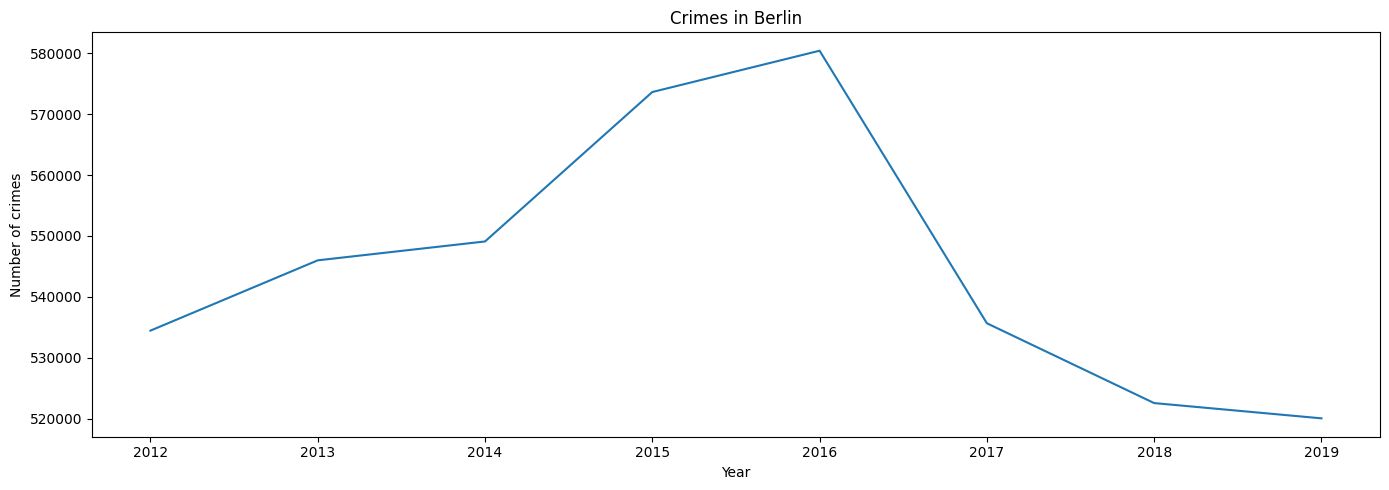

In [40]:
plt.figure(figsize=(14, 5))

ax: Axes = sns.lineplot(
    data=crimes_by_year,
    x="Year",
    y="Total_crimes"
)
ax.set_title("Crimes in Berlin")
ax.set_ylabel("Number of crimes")

plt.tight_layout()
plt.savefig("data/images/q1_crimes_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
crime_decline: int = crimes_by_year.Total_crimes[6] - crimes_by_year.Total_crimes[0]
print("Crime decline 2012-2019:", crime_decline)

Crime decline 2012-2019: -11887


We can observe that, in relative terms, crimes in Berlin have been growing year-over-year from 2012 to 2016, with a spike in 2015-2016, and they have been steadily declining from 2017 to 2019. We can also note that the total crimes in 2019 are ~12k less than in 2012, suggesting a decline in crime rates for the overall period considered.

In [14]:
avg_yearly_crimes: int = crimes_by_year.Total_crimes.mean().__round__()
crime_rate_per_100k_people: int = round(avg_yearly_crimes * 100000 / 3380000)

print("Average crime rate (2012-2019) for 100k people:", crime_rate_per_100k_people)

Average crime rate (2012-2019) for 100k people: 16131


However, in absolute terms, Berlin crime rates is quite high. With Germany averaging at around ~6.5k crimes per 100k people (own calculation from data available in the [official police report](https://www.bka.de/SharedDocs/Downloads/DE/Publikationen/PolizeilicheKriminalstatistik/2019/Bund/Faelle/BU-F-02-T01-Fallentw_csv.csv?__blob=publicationFile&v=9) from 2019), between 2012 and 2019 **Berlin maintains ~16k per 100k people**, more than twice as much!

### 2. How have districts evolved over time, either getting safer, more dangerous, or remaining the same?

In [15]:
district_crimes_by_year: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        SELECT
            `Year`,
            District,
            SUM(
                Robbery +
                Street_robbery +
                Injury +
                Agg_assault +
                Threat +
                Theft +
                Car +
                From_car +
                Bike +
                Burglary +
                Fire +
                Arson +
                Damage +
                Graffiti +
                Drugs +
                Neighbour_disputes
            ) AS Total_crimes
        FROM berlin_crimes
        GROUP BY `Year`, District
        ORDER BY `Year` ASC, Total_crimes DESC;
    """),
    con=conn
)

display(district_crimes_by_year)

,Year,District,Total_crimes
0,2012,Mitte,88278
1,2012,Friedrichshain-Kreuzberg,57969
2,2012,Charlottenburg-Wilmersdorf,57053
3,2012,Neukölln,52212
4,2012,Pankow,49149
...,...,...,...
91,2019,Treptow-Köpenick,30422
92,2019,Steglitz-Zehlendorf,29080
93,2019,Reinickendorf,27846
94,2019,Spandau,26872


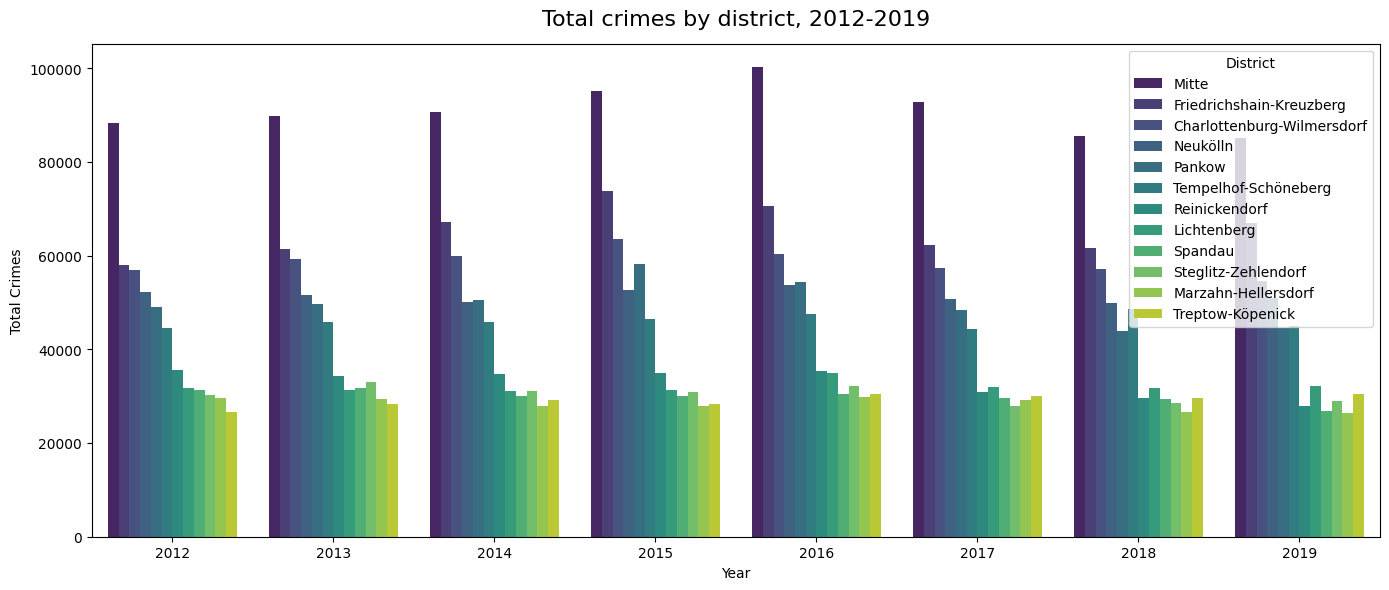

In [ ]:
plt.figure(figsize=(14, 6))

ax: Axes = sns.barplot(
    data=district_crimes_by_year,
    x="Year",
    y="Total_crimes",
    hue="District",
    palette="viridis"
)
ax.set_title("Total crimes by district, 2012-2019", fontsize=16, y=1.02)
ax.set_ylabel("Total Crimes")

plt.tight_layout()
plt.savefig("data/images/q2_district_crimes_bar.png", dpi=150, bbox_inches="tight")
plt.show()

At first glance, it seems that variation year-over-year is minimal, both at the city and at the district level.

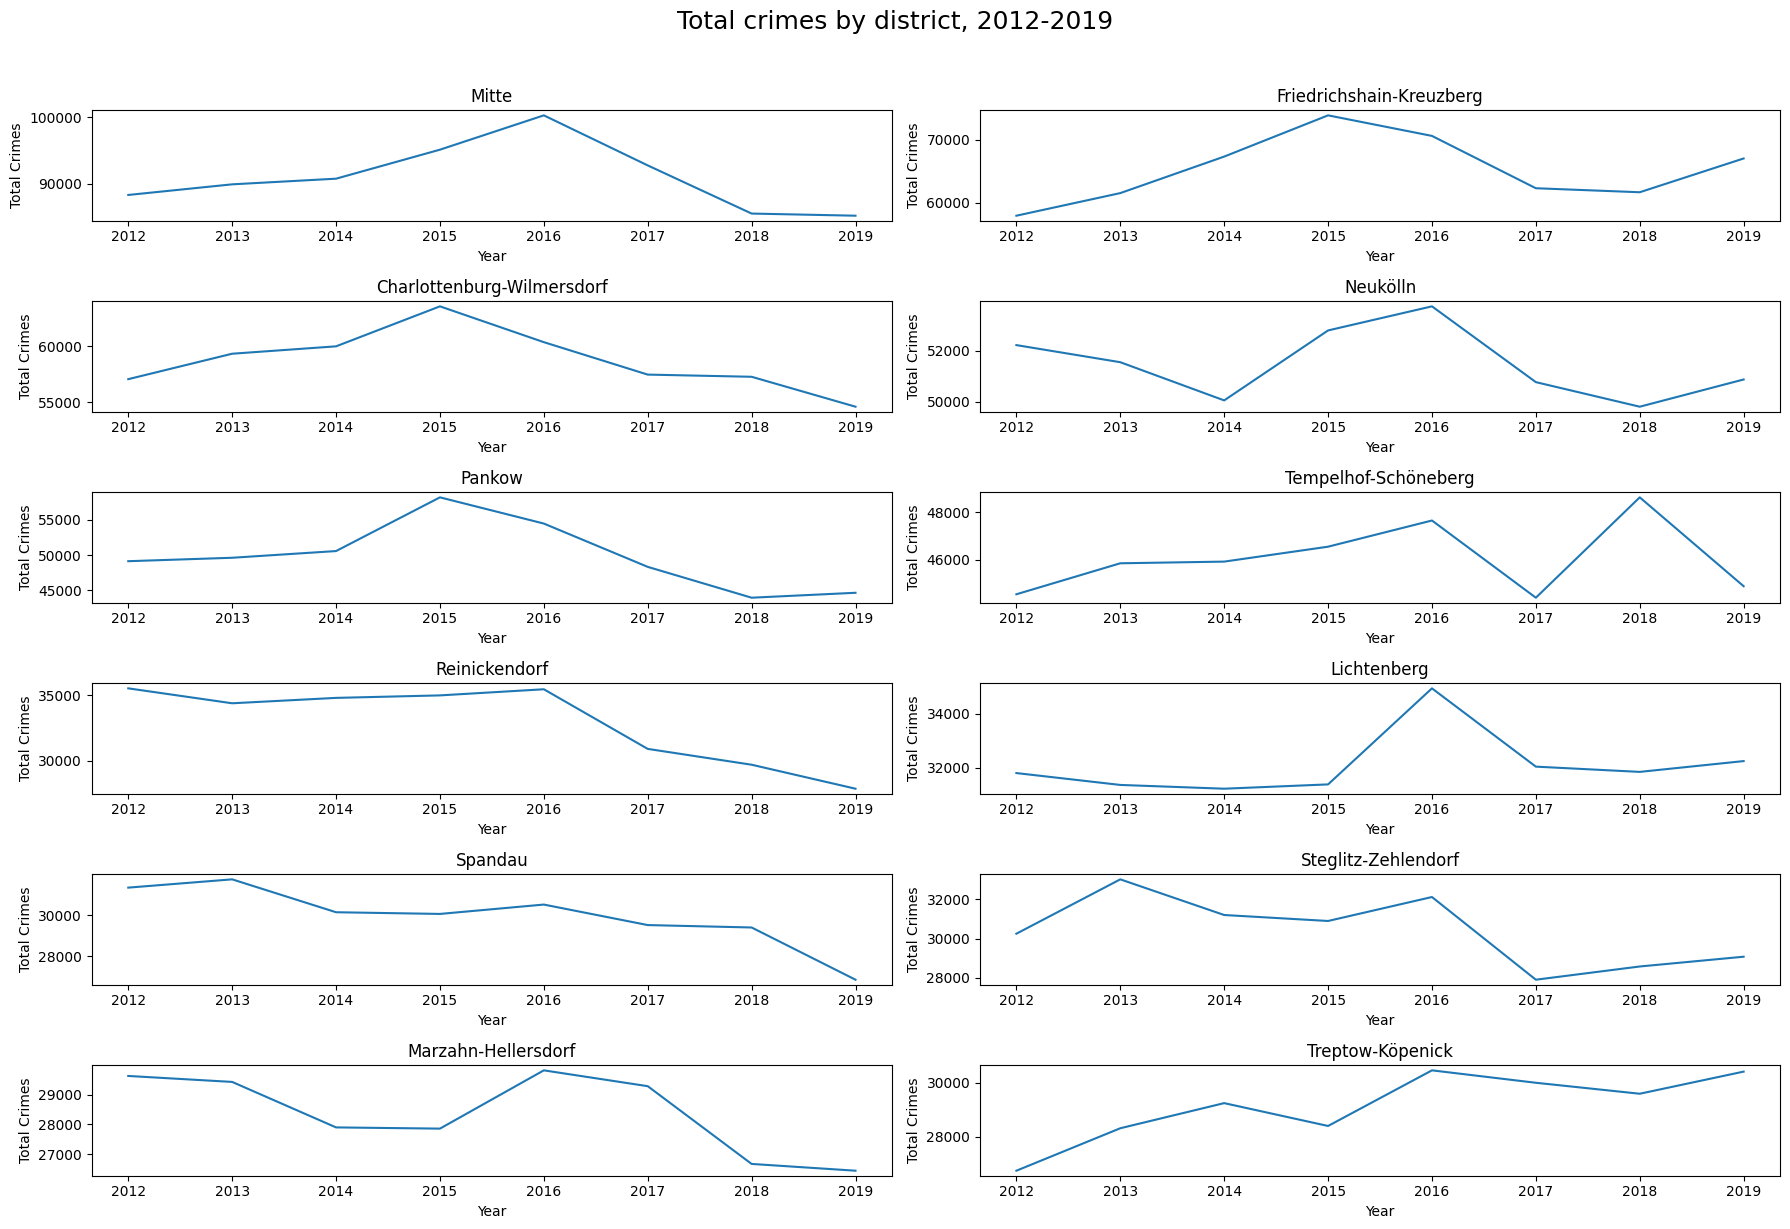

In [ ]:
fig, axes = plt.subplots(6, 2, figsize=(18, 12))
axes = axes.flatten()

districts = district_crimes_by_year["District"].unique()

for i, district in enumerate(districts):
    df_district = district_crimes_by_year[district_crimes_by_year["District"] == district]
    
    sns.lineplot(
        data=df_district,
        x="Year",
        y="Total_crimes",
        ax=axes[i]
    )
    axes[i].set_title(district)
    axes[i].set_xlabel("Year", y=1.02)
    axes[i].set_ylabel("Total Crimes", x=1.02)

plt.suptitle("Total crimes by district, 2012-2019", fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("data/images/q2_district_crimes_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

Taking a closer look at trends in individual districts, we can draw more informed conclusions:

- **Steadily more dangerous:** Treptow-Köpenick.
- **Steadily safer:** Spandau.

- **More dangerous in recent years:** Friedrichschain-Kreuzberg.
- **Safer in recent years:** Marzhan-Hellersdorf, Stegliz-Zehlendorf, Reinickendorf, Pankow.

- **Consistent overall:** Mitte, Lichtenberg, Neukölln, Charlottenburg-Wilmersdorf, Tempelhof-Schöneberg, with isolated spikes in some years.

N.B. We can also notice that the years 2015-2016 saw crime rising across most if not all districts.

### 3. Is the ratio of violent crime (robbery, assault, injury...) to property crime (theft, burglary, damage...) constant, or does it shift across districts?

In [18]:
violent_property_crime_by_district: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        WITH violent_property_crime_by_district_cte AS (
            SELECT
                District,
                SUM(Robbery + Street_robbery + Injury + Agg_assault + Threat) AS Violent_crimes,
                SUM(
                    Theft +
                    Car +
                    From_car +
                    Bike +
                    Burglary +
                    Fire +
                    Arson +
                    Damage +
                    Graffiti
                ) AS Property_crimes
            FROM berlin_crimes
            GROUP BY District
        )
        
        SELECT
            *,
            (Violent_crimes + Property_crimes) AS Total_crimes,
            ROUND(Violent_crimes * 1.0 / (Violent_crimes + Property_crimes), 2) AS Violent_ratio,
            ROUND(Property_crimes * 1.0 / (Violent_crimes + Property_crimes), 2) AS Property_ratio
        FROM violent_property_crime_by_district_cte
        ORDER BY District;
    """),
    con=conn
)

display(violent_property_crime_by_district)

,District,Violent_crimes,Property_crimes,Total_crimes,Violent_ratio,Property_ratio
0,Charlottenburg-Wilmersdorf,57367,322982,380349,0.15,0.85
1,Friedrichshain-Kreuzberg,70241,331618,401859,0.17,0.83
2,Lichtenberg,34904,169569,204473,0.17,0.83
3,Marzahn-Hellersdorf,39175,136067,175242,0.22,0.78
4,Mitte,104295,470501,574796,0.18,0.82
5,Neukölln,60181,256615,316796,0.19,0.81
6,Pankow,40516,283750,324266,0.12,0.88
7,Reinickendorf,40540,163420,203960,0.20,0.80
8,Spandau,39873,143191,183064,0.22,0.78
9,Steglitz-Zehlendorf,25485,177265,202750,0.13,0.87


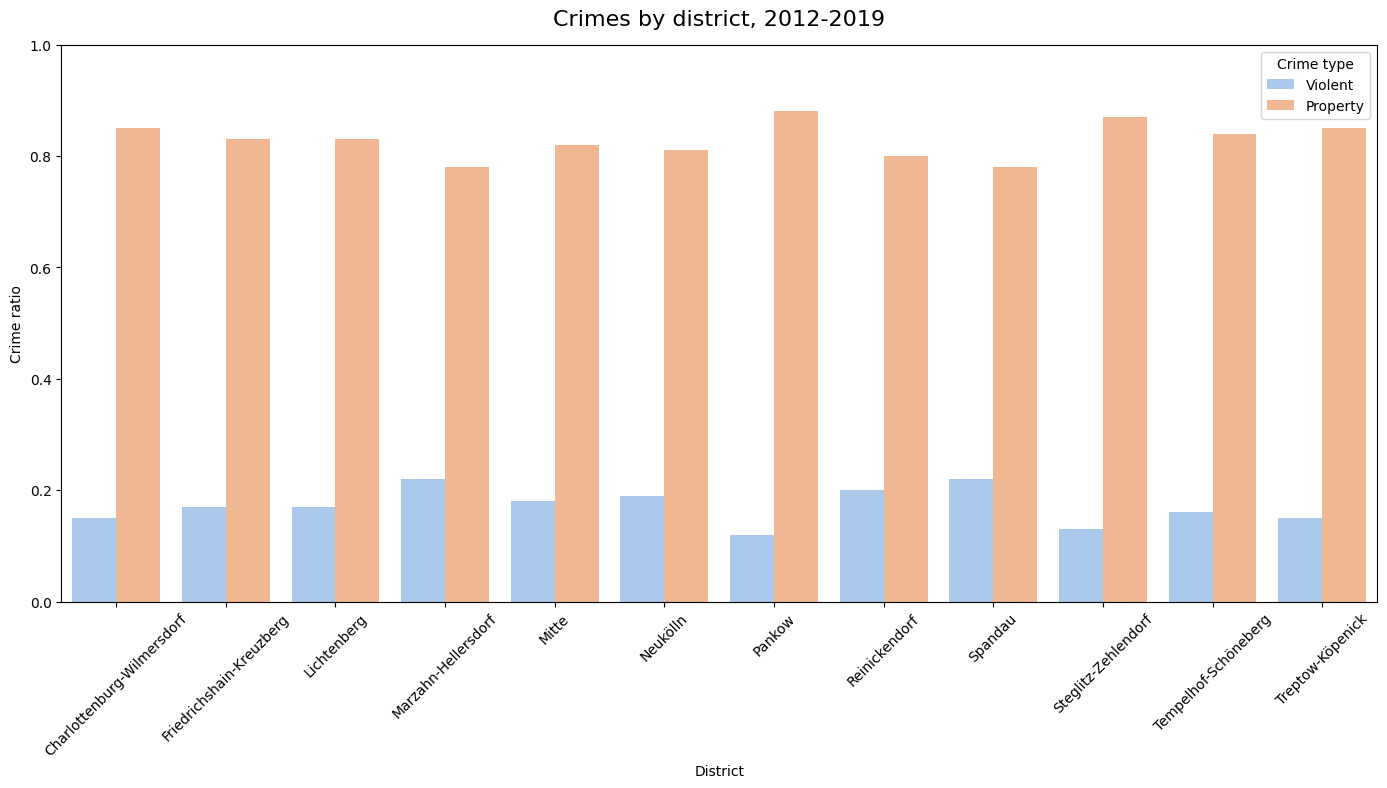

In [44]:
long_format_df: pd.DataFrame = violent_property_crime_by_district.melt(
    id_vars="District",
    value_vars=["Violent_ratio", "Property_ratio"],
    var_name="Crime_type",
    value_name="Ratio"
)

plt.figure(figsize=(14, 8))

ax: Axes = sns.barplot(
    data=long_format_df,
    x="District",
    y="Ratio",
    hue="Crime_type",
    palette="pastel"
)
ax.set_title("Crimes by district, 2012-2019", fontsize=16, y=1.02)
ax.set_ylabel("Crime ratio", x=1.02)
ax.set_ylim(0, 1)

ax.legend(
    handles=ax.get_legend_handles_labels()[0],
    labels=["Violent", "Property"],
    title="Crime type"
)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("data/images/q3_ratio_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
violent_ratio_mean: float = violent_property_crime_by_district.Violent_ratio.mean().__round__(2)
violent_ratio_std: float = violent_property_crime_by_district.Violent_ratio.std().__round__(2)

property_ratio_mean: float = violent_property_crime_by_district.Property_ratio.mean().__round__(2)
property_ratio_std: float = violent_property_crime_by_district.Property_ratio.std().__round__(2)

print("Violent crime %:", violent_ratio_mean * 100)
print("Violent crime variability:", violent_ratio_std, "\n")

print("Property crime %:", property_ratio_mean * 100)
print("Property crime variability:", property_ratio_std)

Violent crime %: 17.0
Violent crime variability: 0.03 

Property crime %: 83.0
Property crime variability: 0.03


Both the graph and the statistical results suggest that the proportion of violent-to-property crimes is quite consistend across the city, with minimal variation.

### 4. Is there a single location that leads for violent crimes every year?

In [21]:
location_violent_crimes_by_year: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        WITH location_violent_crimes_by_year_cte AS (
            SELECT
                `Year`,
                `Location`,
                Code,
                District,
                SUM(Robbery + Street_robbery + Injury + Agg_assault + Threat) AS Violent_crimes
            FROM berlin_crimes
            GROUP BY `Year`, `Location`, Code
        )
            
        SELECT
            `Year`,
            `Location`,
            Code,
            District,
            MAX(Violent_crimes) AS Violent_crimes
        FROM location_violent_crimes_by_year_cte
        GROUP BY `Year`
        ORDER BY `Year` ASC;
    """),
    con=conn
)

display(location_violent_crimes_by_year)

,Year,Location,Code,District,Violent_crimes
0,2012,Alexanderplatz,10113,Mitte,2677
1,2013,Alexanderplatz,10113,Mitte,2515
2,2014,Alexanderplatz,10113,Mitte,2332
3,2015,Alexanderplatz,10113,Mitte,2415
4,2016,Alexanderplatz,10113,Mitte,2286
5,2017,Alexanderplatz,10113,Mitte,2791
6,2018,Alexanderplatz,10113,Mitte,2416
7,2019,Alexanderplatz,10113,Mitte,3161


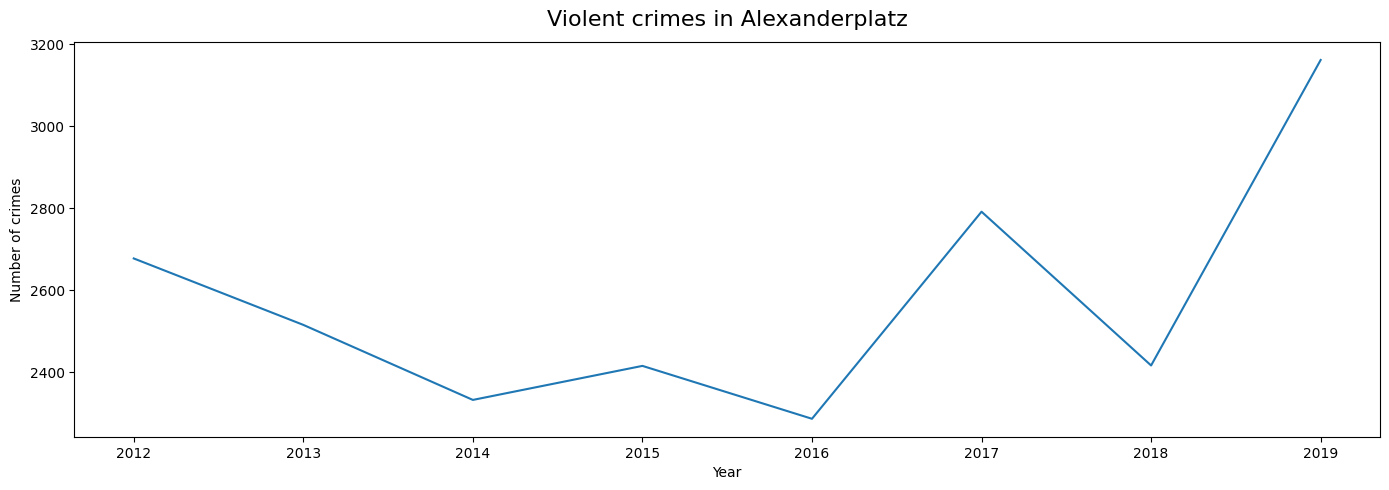

In [ ]:
plt.figure(figsize=(14, 5))

ax: Axes = sns.lineplot(
    data=location_violent_crimes_by_year,
    x="Year",
    y="Violent_crimes"
)
ax.set_title("Violent crimes in Alexanderplatz", fontsize=16, y=1.02)
ax.set_ylabel("Number of crimes", x=1.02)

plt.tight_layout()
plt.savefig("data/images/q4_alexanderplatz_crimes.png", dpi=150, bbox_inches="tight")
plt.show()

As we can clearly see from the results, **Alexanderplatz** is the location (area code) with the highest number of violent crimes in any given year, for the period 2012 to 2019. Moreover, crime rates follow an inconsistent trend, but do spike quite significantly in 2019.

### 5. Which are the bottom 3 locations for amount of drug-related crimes, in the years between 2016 and 2019? And which are the top 3?

In [23]:
drug_crimes_2016_2019_by_location: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        SELECT
            `Location`,
            Code,
            District,
            CAST(ROUND(AVG(Drugs)) AS INT) AS Avg_drug_crimes
        FROM berlin_crimes
        WHERE `Year` BETWEEN 2016 AND 2019
        GROUP BY `Location`, Code
        ORDER BY Avg_drug_crimes DESC;
    """),
    con=conn
)

display(drug_crimes_2016_2019_by_location)

,Location,Code,District,Avg_drug_crimes
0,Frankfurter Allee Süd FK,20508,Friedrichshain-Kreuzberg,1087
1,südliche Luisenstadt,20304,Friedrichshain-Kreuzberg,1026
2,Alexanderplatz,10113,Mitte,861
3,Südliche Friedrichstadt,20101,Friedrichshain-Kreuzberg,793
4,Moabit West,10221,Mitte,622
...,...,...,...,...
145,Grünau,90311,Treptow-Köpenick,6
146,Müggelheim,90416,Treptow-Köpenick,5
147,"Malchow, Wartenberg und Falkenberg",110101,Lichtenberg,3
148,Forst Grunewald,40617,Charlottenburg-Wilmersdorf,2


In [24]:
bottom_3_locations: pd.DataFrame = drug_crimes_2016_2019_by_location[:-4:-1]
display(bottom_3_locations)

,Location,Code,District,Avg_drug_crimes
149,Schmöckwitz/Karolinenhof/Rauchfangswerder,90312,Treptow-Köpenick,2
148,Forst Grunewald,40617,Charlottenburg-Wilmersdorf,2
147,"Malchow, Wartenberg und Falkenberg",110101,Lichtenberg,3


The 3 locations with the least drug-related crimes between 2016 and 2019 are: **Forst Grunewald**, **Schmöckwitz/Karolinenhof/Rauchfangswerder**, and **Malchow/Wartenberg/Falkenberg**.

In [25]:
top_3_locations: pd.DataFrame = drug_crimes_2016_2019_by_location[:3]
display(top_3_locations)

,Location,Code,District,Avg_drug_crimes
0,Frankfurter Allee Süd FK,20508,Friedrichshain-Kreuzberg,1087
1,südliche Luisenstadt,20304,Friedrichshain-Kreuzberg,1026
2,Alexanderplatz,10113,Mitte,861


The 3 districts with the highest amoung of drug-related crimes between 2016 and 2019 are: **Frankfurter Allee Süd FK**, **Südliche Luisenstadt**, and **Alexanderplatz**.

### 6. Are drug crimes a leading indicator for violent crimes across the city?

In [26]:
drug_and_violent_crimes: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        SELECT
            District,
            Drugs,
            (Robbery + Street_robbery + Injury + Agg_assault + Threat) AS Violent_crimes
        FROM berlin_crimes;
    """),
    con=conn
)

display(drug_and_violent_crimes)

,District,Drugs,Violent_crimes
0,Mitte,171,1014
1,Mitte,98,833
2,Mitte,435,2677
3,Mitte,213,457
4,Mitte,259,1194
...,...,...,...
1195,Reinickendorf,110,633
1196,Reinickendorf,73,865
1197,Reinickendorf,21,147
1198,Reinickendorf,31,168


In [27]:
drug_and_violent_crimes.describe().round(2)

,Drugs,Violent_crimes
count,1200.00,1200.00
mean,97.86,490.64
std,174.80,426.66
min,0.00,10.00
25%,18.00,193.00
50%,40.00,363.50
75%,86.00,619.25
max,1949.00,3161.00


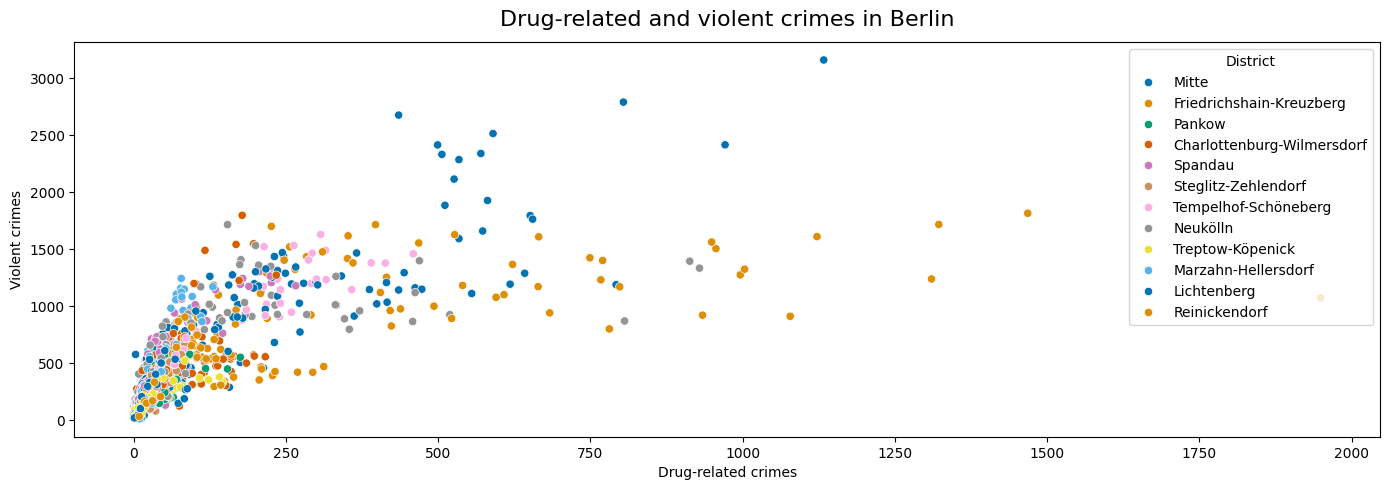

In [28]:
plt.figure(figsize=(14, 5))

ax: Axes = sns.scatterplot(
    data=drug_and_violent_crimes,
    x="Drugs",
    y="Violent_crimes",
    hue="District",
    palette="colorblind"
)
ax.set_title("Drug-related and violent crimes in Berlin", fontsize=16, y=1.02)
ax.set_xlabel("Drug-related crimes", y=1.02)
ax.set_ylabel("Violent crimes", x=1.02)

plt.tight_layout()
plt.show()

Looking at the scatterplot and the measures of central tendency and dispersion, we notice that there are definite outliers in this data, which may prevent us from gaining significant insight. Let's reduce the extremes of the dataset.

In [29]:
drug_and_violent_crimes_reduced: pd.DataFrame = drug_and_violent_crimes[
    (drug_and_violent_crimes.Drugs <= 750) & (drug_and_violent_crimes.Violent_crimes <= 2000)
]

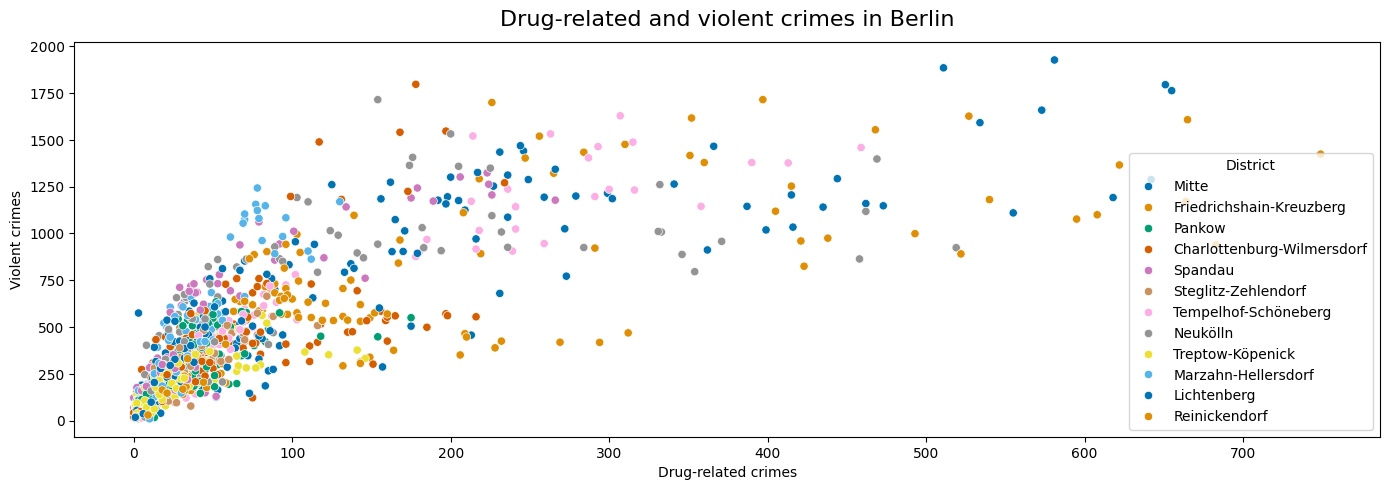

In [30]:
plt.figure(figsize=(14, 5))

ax: Axes = sns.scatterplot(
    data=drug_and_violent_crimes_reduced,
    x="Drugs",
    y="Violent_crimes",
    hue="District",
    palette="colorblind"
)
ax.set_title("Drug-related and violent crimes in Berlin", fontsize=16, y=1.02)
ax.set_xlabel("Drug-related crimes", y=1.02)
ax.set_ylabel("Violent crimes", x=1.02)

plt.tight_layout()
plt.show()

This is an already improved view. For the sake of visualization, we will now display only the data falling within Q3 (the third quartile).

In [31]:
drug_and_violent_crimes_q3: pd.DataFrame = drug_and_violent_crimes_reduced[
    (drug_and_violent_crimes_reduced.Drugs <= 86) & (drug_and_violent_crimes_reduced.Violent_crimes <= 620)
]

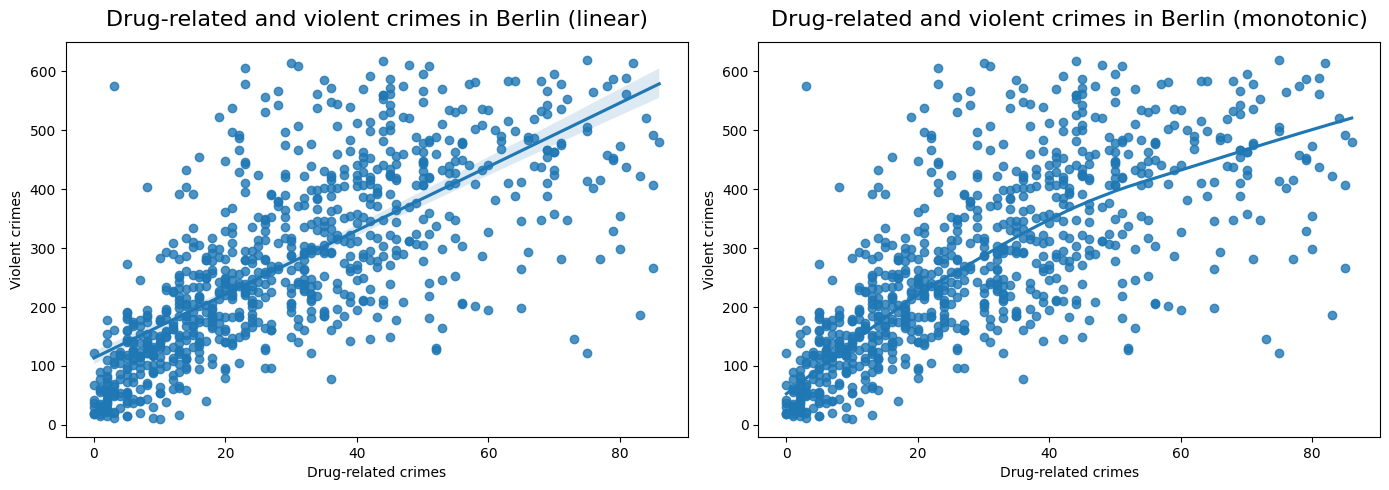

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=drug_and_violent_crimes_q3,
    x="Drugs",
    y="Violent_crimes",
    ax=axes[0]
)
axes[0].set_title("Drug-related and violent crimes in Berlin (linear)", fontsize=16, y=1.02)
axes[0].set_xlabel("Drug-related crimes", y=1.02)
axes[0].set_ylabel("Violent crimes", x=1.02)

sns.regplot(
    data=drug_and_violent_crimes_q3,
    x="Drugs",
    y="Violent_crimes",
    lowess=True,
    ax=axes[1]
)
axes[1].set_title("Drug-related and violent crimes in Berlin (monotonic)", fontsize=16, y=1.02)
axes[1].set_xlabel("Drug-related crimes", y=1.02)
axes[1].set_ylabel("Violent crimes", x=1.02)

plt.tight_layout()
plt.savefig("data/images/q6_drug_to_violence_regression.png", dpi=150, bbox_inches="tight")
plt.show()

This regression plot on the most dense segment provides a much more insightful view of the data, strongly suggesting the existence of a clear linear relationship between drug-related and violent crimes, at least for some districts. Let's now compute some statistics to confirm this educated guess.

In [33]:
pearson_r: float = round(float(
    drug_and_violent_crimes.Drugs.corr(drug_and_violent_crimes.Violent_crimes, method="pearson")),
    2
)
spearman_p: float = round(float(
    drug_and_violent_crimes.Drugs.corr(drug_and_violent_crimes.Violent_crimes, method="spearman")),
    2
)

print("Pearson's r:", pearson_r)
print("Spearman's p", spearman_p)

Pearson's r: 0.72
Spearman's p 0.87


The results confirm our intuition. A **linear correlation of 0.72** is quite strong, indicating that higher drug-related crimes are tied to higher violent crimes. An even stronger **monotonic correlation of 0.87** does suggest that this in fact the case, even when the association is not completely linear, it still grows together. So *we can conclude that drug crimes are indeed a leading indicator of violent crimes around the city*.

Nevertheless, it is important to make two notes. First, this association does not imply causation, but only that a link between the two phenomena exists. Second, looking at the high standard deviation and the scatterplots, we can see that the data is not particularly dense around the mean. This means that not in every case higher drug-related crimes come together with higher violent crimes. Taking into account the district-based, color-coding, we can also notice that higher numbers are sometimes related to specific district, introducing more complexity to the subject matter. Thus, *we cannot conclude any direct causation between the two phenomena*.

### 7. Which locations are generating disproportionate crime relative to their district average?

In [34]:
locations_over_district_avg: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        WITH avg_crime_by_district_cte AS (
            SELECT
                District,
                CAST(ROUND(AVG(
                    Robbery +
                    Street_robbery +
                    Injury +
                    Agg_assault +
                    Threat +
                    Theft +
                    Car +
                    From_car +
                    Bike +
                    Burglary +
                    Fire +
                    Arson +
                    Damage +
                    Graffiti +
                    Drugs +
                    Neighbour_disputes
                )) AS INT) AS Avg_district_crimes
            FROM berlin_crimes
            GROUP BY District
        ),    
        avg_crime_by_location_cte AS (
            SELECT
                District,
                `Location`,
                Code,
                CAST(ROUND(AVG(
                    Robbery +
                    Street_robbery +
                    Injury +
                    Agg_assault +
                    Threat +
                    Theft +
                    Car +
                    From_car +
                    Bike +
                    Burglary +
                    Fire +
                    Arson +
                    Damage +
                    Graffiti +
                    Drugs +
                    Neighbour_disputes
                )) AS INT) AS Avg_location_crimes
            FROM berlin_crimes
            GROUP BY `Location`, District
        )
        
        SELECT
            cl.District,
            cl.`Location`,
            cl.Code,
            cl.Avg_location_crimes,
            cd.Avg_district_crimes,
            cl.Avg_location_crimes - cd.Avg_district_crimes AS Surplus
        FROM avg_crime_by_location_cte cl
        JOIN avg_crime_by_district_cte cd
          ON cl.District = cd.District
        WHERE
            cl.Avg_location_crimes > cd.Avg_district_crimes
            AND Surplus > 2000 -- Arbitrary threshold for more significant results
        ORDER BY Surplus DESC;
    """),
    con=conn
)

display(locations_over_district_avg)

,District,Location,Code,Avg_location_crimes,Avg_district_crimes,Surplus
0,Mitte,Alexanderplatz,10113,20794,8269,12525
1,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,20202,12955,7253,5702
2,Charlottenburg-Wilmersdorf,Kurfürstendamm,40309,8724,3261,5463
3,Tempelhof-Schöneberg,Schöneberg-Nord,70101,10989,5757,5232
4,Neukölln,Neuköllner Mitte/Zentrum,80102,9794,4679,5115
5,Friedrichshain-Kreuzberg,Frankfurter Allee Süd FK,20508,11738,7253,4485
6,Tempelhof-Schöneberg,Tempelhof,70404,9459,5757,3702
7,Spandau,Spandau Mitte,50103,6636,2995,3641
8,Marzahn-Hellersdorf,Marzahn-Mitte,100102,5871,2838,3033
9,Lichtenberg,Alt-Lichtenberg,110307,5177,2293,2884


### 8. What is the district with the highest number of neighbour disputes, on average, between 2014 and 2018?

In [35]:
district_neighbour_disputes_2014_2018: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        SELECT
            District,
            CAST(ROUND(AVG(Neighbour_disputes)) AS INT) AS Avg_neighbour_disputes
        FROM berlin_crimes
        WHERE `Year` BETWEEN 2014 AND 2018
        GROUP BY District
        ORDER BY Avg_neighbour_disputes DESC
        LIMIT 1;
    """),
    con=conn
)

display(district_neighbour_disputes_2014_2018)

,District,Avg_neighbour_disputes
0,Mitte,1411


Between 2014 and 2018, **Mitte** has been the district with the highest average of neighbour disputes.

### 9. Which is the top location in each districts that should get targeted enforcement for bike theft?

In [36]:
location_bike_theft_by_district: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        WITH location_bike_theft_by_district_cte AS (
            SELECT
                District,
                `Location`,
                Code,
                SUM(Bike) AS Bike_theft
            FROM berlin_crimes
            GROUP BY District, `Location`, Code
        )
        
        SELECT
            District,
            `Location`,
            Code,
            MAX(Bike_theft) AS Bike_theft
        FROM location_bike_theft_by_district_cte
        GROUP BY District
        ORDER BY Bike_theft DESC;
    """),
    con=conn
)

display(location_bike_theft_by_district)

,District,Location,Code,Bike_theft
0,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,20202,8908
1,Mitte,Alexanderplatz,10113,7919
2,Tempelhof-Schöneberg,Schöneberg-Süd,70202,5306
3,Pankow,Pankow Zentrum,30406,4429
4,Neukölln,Reuterstraße,80103,3421
5,Charlottenburg-Wilmersdorf,Volkspark Wilmersdorf,40516,3420
6,Steglitz-Zehlendorf,Teltower Damm,60305,2914
7,Lichtenberg,Neu Lichtenberg,110409,2469
8,Treptow-Köpenick,Alt-Treptow,90101,2188
9,Spandau,Spandau Mitte,50103,2050


### 10. Which district shows the greatest crime volatility year-to-year?

In [37]:
district_crime_volatility: pd.DataFrame = pd.read_sql_query(
    sa.text("""
        WITH district_crime_by_year AS (
            SELECT
                `Year`,
                District,
                SUM(
                    Robbery +
                    Street_robbery +
                    Injury +
                    Agg_assault +
                    Threat +
                    Theft +
                    Car +
                    From_car +
                    Bike +
                    Burglary +
                    Fire +
                    Arson +
                    Damage +
                    Graffiti +
                    Drugs +
                    Neighbour_disputes
                ) AS Total_crimes
            FROM berlin_crimes
            GROUP BY `Year`, District
        )
            
        SELECT
            District,
            ROUND(
                SQRT(AVG(Total_crimes * Total_crimes) - AVG(Total_crimes) * AVG(Total_crimes)) -- Manual formulat for STDEV
                    / AVG(Total_crimes) * 1.0,
                4
            ) AS Var_coeff
        FROM district_crime_by_year
        GROUP BY District
        ORDER BY Var_coeff DESC
        LIMIT 1;
    """),
    con=conn
)

display(district_crime_volatility)

,District,Var_coeff
0,Pankow,0.0886


In [38]:
# -- Check result since using manual formula for stdev
# district_crime_volatility: pd.Series = district_crime_volatility.groupby("District")["Total_crimes"]
# district_crime_volatility.std() / district_crime_volatility.mean()

**Pankow** shows the greatest crime volatility year-to-year.

In [39]:
# Close db connection
conn.close()